# -- README --
# LeNet-5 vs LeNet-3

## Context:
### This project is part of a group assignment at UiT that asks:
  1. Modify the LeNet-5 architecture such that instead of 3 conv layers and 2 fc layers it should have 2 conv layers and 1 fc layer.
  2. How can we do that and what changes are needed in LeNet-5 to change it to LeNet-3?
  3. Compare the training plots of LeNet-3 with LeNet-5 and the results from testing the two models (using the same optimizer and number of epochs)
  4. Provide Github code links

## Method:
Example/template code provided by the instructors' github ( https://github.com/puneetnorge/Machine-Vision ) was copied, adapted and experimented with to solve the assigment.  
Two datasets, MNIST and CIFAR-10 were used to experiment and compare the difference between LeNet-5 and LeNet-3.
*   MNIST: Handwritten numbers from 0 to 9
*   CIFAR-10: pictures containing 10 classes of objects (cat, frog, car, boat, ...)

## Solution
  1. The example LeNet-5 model consisted of two conv layers (w/ pooling), two fc layers and one output layer. To modify this model to consist of only 3 layers, two of the inner fc layers were removed.  
  To make both datasets fit through both models, MNIST was transformed from 28x28 -> 32x32 to match the resolution of CIFAR-10. The transformation was done with black-pixel-padding.
  2. For the chosen datasets and the LeNet-5 example code we made LeNet-3 from LeNet-5 by removing two fc layers and modifying the last standing fc layer to correctly reciev the in_features.
  3. The two removed fc layers did not seem to impact the performance of LeNet for the MNIST dataset. This is likely because handwritten numbers have low complexity, and are likely allready "solved" be the LeNet-3 layers. LeNet-5 = LeNet-3 for MNIST.  
  For the CIFAR-10 dataset none of the models perform very well. We suspected the LeNet-5 to outperform LeNet-3, but this didn't happen. What happened was the LeNet-5 started overfitting very early in the training, and seemed to underperform compared to LeNet-3




# Cell 1: Imports and device

In [ ]:
import torch                                                                    # tensors, device (cpu/gpu), no_grad, argmax via torch.max
import torch.nn as nn                                                           # layers: Conv2d, AvgPool2d, Linear, and CrossEntropyLoss
import torch.nn.functional as F                                                 # stateless ops used in forward, here F.relu
import torch.optim as optim                                                     # optimizers; Adam updates the weights from the loss
from torch.utils.data import DataLoader, random_split                           # DataLoader: groups images into batches
from torchvision import datasets, transforms, utils                             # random_split: cuts the training set into train and validation
import matplotlib.pyplot as plt                                                 # datasets: MNIST and CIFAR-10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")           # transforms: resize, grayscale, ToTensor, Normalize
print(device)                                                                   # utils: utils.make_grid, used to preview a batch


cpu


# Cell 2: Datasets

Loading and splitting datasets, and setting transforms.

MNIST: 28x28 grayscale handwritten numbers from 0-9, low complexity

CIFAR-10: 32x32 RGB pictures of 10 different objects, higher complexity

In [ ]:
mnist_transform = transforms.Compose([
    transforms.Pad(2),                                                          # 28 -> 32, black border pixel padding to match CIFARs res.
    transforms.Grayscale(num_output_channels=3),                                # match CIFARs nr of channels
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

cifar_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])


'''  Standard code from https://pytorch.org/vision/stable/datasets.html  '''

# Load datasets
mnist_train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=mnist_transform)
mnist_test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=mnist_transform)
cifar_train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=cifar_transform)
cifar_test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=cifar_transform)

# Make loaders function
def make_loaders(train_dataset, test_dataset, batch_size=64):
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_set, val_set = random_split(train_dataset, [train_size, val_size])

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

# Calling loader for each dataset
mnist_train_loader, mnist_val_loader, mnist_test_loader = make_loaders(mnist_train_dataset, mnist_test_dataset)
cifar_train_loader, cifar_val_loader, cifar_test_loader = make_loaders(cifar_train_dataset, cifar_test_dataset)

# Taking first pile of each loader, then printing shape
mnist_images, mnist_labels = next(iter(mnist_train_loader))                     # iter: put hand in box
cifar_images, cifar_labels = next(iter(cifar_train_loader))                     # next: pull out first pile
print("MNIST batch:", mnist_images.shape, "labels:", mnist_labels.shape)
print("CIFAR batch:", cifar_images.shape, "labels:", cifar_labels.shape)

100%|██████████| 9.91M/9.91M [00:00<00:00, 15.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 449kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.15MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.64MB/s]
100%|██████████| 170M/170M [00:07<00:00, 22.4MB/s]


MNIST batch: torch.Size([64, 3, 32, 32]) labels: torch.Size([64])
CIFAR batch: torch.Size([64, 3, 32, 32]) labels: torch.Size([64])


# Cell 3: Look at data

Look at sample from datasets

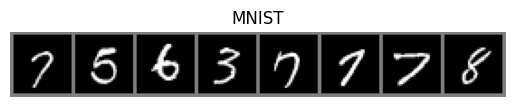

7 7
5 5
6 6
3 3
7 7
7 7
7 7
8 8


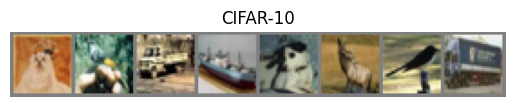

5 dog
2 bird
9 truck
8 ship
5 dog
4 deer
2 bird
9 truck


In [ ]:
cifar_names = cifar_train_dataset.classes   # airplane, automobile, bird, ...

def show_batch(images, labels, title, names=None):
    grid = utils.make_grid(images[:8]) / 2 + 0.5
    grid = grid.clamp(0, 1)
    plt.imshow(grid.permute(1, 2, 0))
    plt.title(title)
    plt.axis("off")
    plt.show()
    for n in labels[:8].tolist():
        word = names[n] if names is not None else str(n)
        print(n, word)

show_batch(mnist_images, mnist_labels, "MNIST")
show_batch(cifar_images, cifar_labels, "CIFAR-10", cifar_names)

# Cell 4: Models

 Setting up LeNet-5 and LeNet-3

In [ ]:
class LeNet5(nn.Module):
    def __init__(self, num_of_classes):
        # Initialize the parent class (nn.Module)
        super(LeNet5, self).__init__()

        # Layer 1: Convolutional + Pooling
        ''' we are using three channels as input (instead of 1) to fit both MNIST and CIFAR-10 in the same model '''
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, stride=1, padding=2)   # 32x32 -> 32x32
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)                                          # 32x32 -> 16x16

        # Layer 2: Convolutional + Pooling
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1)             # 16x16 -> 12x12
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)                                          # 12x12 -> 6x6

        # Layer 3: Fully Connected
        self.fc1 = nn.Linear(in_features=16*6*6, out_features=120)

        # Layer 4: Fully Connected
        self.fc2 = nn.Linear(in_features=120, out_features=84)

        # Layer 5: Output Layer
        self.fc3 = nn.Linear(in_features=84, out_features=num_of_classes)

    def forward(self, x):
        # Layer 1: Conv -> Pool -> Activation
        x = F.relu(self.pool1(self.conv1(x)))

        # Layer 2: Conv -> Pool -> Activation
        x = F.relu(self.pool2(self.conv2(x)))

        # Flatten the output from the convolutional layers
        x = x.view(-1, 16 * 6 * 6)

        # Layer 3: Fully Connected + Activation
        x = F.relu(self.fc1(x))

        # Layer 4: Fully Connected + Activation
        x = F.relu(self.fc2(x))

        # Layer 5: Fully Connected (Output)
        x = self.fc3(x)

        return x


class LeNet3(nn.Module):
    def __init__(self, num_of_classes):
        # Initialize the parent class (nn.Module)
        ''' Fixed: Changed LeNet5 to LeNet3 '''
        super(LeNet3, self).__init__()

        # Layer 1: Convolutional + Pooling
        ''' we are using three channels as input (instead of 1) to fit both MNIST and CIFAR-10 in the same model '''
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, stride=1, padding=2)   # 32x32 -> 32x32
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)                                          # 32x32 -> 16x16

        # Layer 2: Convolutional + Pooling
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1)             # 16x16 -> 12x12
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)                                          # 12x12 -> 6x6

        # Layer 3: Output Layer (Single Fully Connected Layer)
        ''' Fixed: Input features must match the flattened output from conv2 (16*6*6) '''
        self.fc1 = nn.Linear(in_features=16*6*6, out_features=num_of_classes)

    def forward(self, x):
        # Layer 1: Conv -> Pool -> Activation
        x = F.relu(self.pool1(self.conv1(x)))

        # Layer 2: Conv -> Pool -> Activation
        x = F.relu(self.pool2(self.conv2(x)))

        # Flatten the output from the convolutional layers
        x = x.view(-1, 16 * 6 * 6)

        # Layer 3: Fully Connected (Output)
        x = self.fc1(x)

        return x


# Creating a model object/instance
model_LeNet5 = LeNet5(num_of_classes=10)
model_LeNet3 = LeNet3(num_of_classes=10)

print(model_LeNet5)
print(model_LeNet3)

LeNet5(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (fc1): Linear(in_features=576, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
LeNet3(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (fc1): Linear(in_features=576, out_features=10, bias=True)
)


# Cell 5: Training

In [ ]:
def run(model, train_loader, val_loader, epochs=10):
    ''' .to(device): moves tensors and models to the specified device (either GPU or CPU).
    This ensures that all computations happen on the same device, avoiding errors or inefficiencies. '''
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()                                           # Cross Entropy Loss for multi-class classification
    optimizer = optim.Adam(model.parameters(), lr=0.001)                        # Optimizer SGD or ADAM with learning rate

    # Initialize lists to store training and validation metrics
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)                                # torch.max gives the winning class; _ is the score we do not need
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)
        train_accuracy = 100 * correct / total
        train_accuracies.append(train_accuracy)

        model.eval()                                                            # .eval indicates that the model is used for prediction.
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracy = 100 * correct / total
        val_accuracies.append(val_accuracy)

        print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%, Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%')

    return model, train_losses, val_losses, train_accuracies, val_accuracies


print("MNIST on LeNet-5\n")
mnist_m5, *mnist_lenet5 = run(LeNet5(num_of_classes=10), mnist_train_loader, mnist_val_loader, epochs=10)
print("\nMNIST on LeNet-3\n")
mnist_m3, *mnist_lenet3 = run(LeNet3(num_of_classes=10), mnist_train_loader, mnist_val_loader, epochs=10)
print("\nCIFAR-10 on LeNet-5\n")
cifar_m5, *cifar_lenet5 = run(LeNet5(num_of_classes=10), cifar_train_loader, cifar_val_loader, epochs=25)
print("\nCIFAR-10 on LeNet-3\n")
cifar_m3, *cifar_lenet3 = run(LeNet3(num_of_classes=10), cifar_train_loader, cifar_val_loader, epochs=25)

MNIST on LeNet-5

Epoch 1/10, Train Loss: 0.3562, Train Accuracy: 88.47%, Val Loss: 0.1450, Val Accuracy: 95.57%
Epoch 2/10, Train Loss: 0.1104, Train Accuracy: 96.60%, Val Loss: 0.0948, Val Accuracy: 97.11%
Epoch 3/10, Train Loss: 0.0785, Train Accuracy: 97.55%, Val Loss: 0.0831, Val Accuracy: 97.46%
Epoch 4/10, Train Loss: 0.0641, Train Accuracy: 98.02%, Val Loss: 0.0708, Val Accuracy: 97.90%
Epoch 5/10, Train Loss: 0.0531, Train Accuracy: 98.33%, Val Loss: 0.0723, Val Accuracy: 97.81%
Epoch 6/10, Train Loss: 0.0489, Train Accuracy: 98.44%, Val Loss: 0.0679, Val Accuracy: 98.12%
Epoch 7/10, Train Loss: 0.0395, Train Accuracy: 98.74%, Val Loss: 0.0667, Val Accuracy: 98.19%
Epoch 8/10, Train Loss: 0.0362, Train Accuracy: 98.81%, Val Loss: 0.0560, Val Accuracy: 98.33%
Epoch 9/10, Train Loss: 0.0329, Train Accuracy: 98.96%, Val Loss: 0.0588, Val Accuracy: 98.33%
Epoch 10/10, Train Loss: 0.0270, Train Accuracy: 99.10%, Val Loss: 0.0541, Val Accuracy: 98.46%
MNIST on LeNet-3

Epoch 1/10, T

# Cell 6: Results

Comparison plot

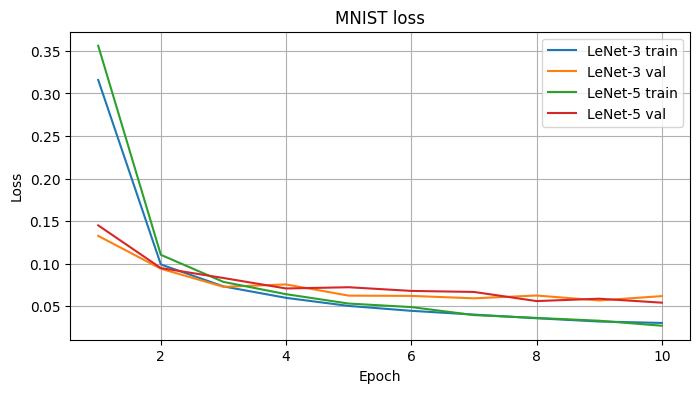

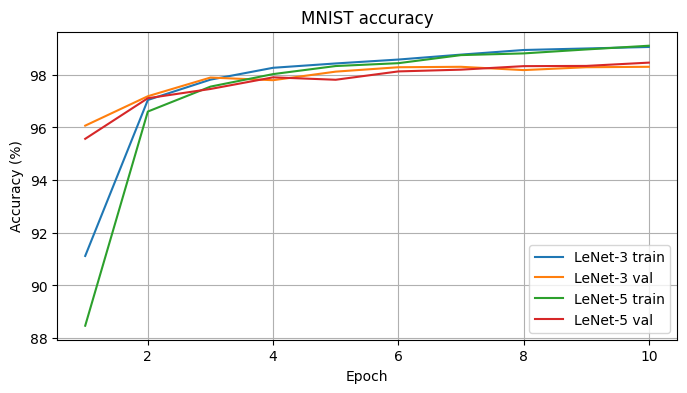

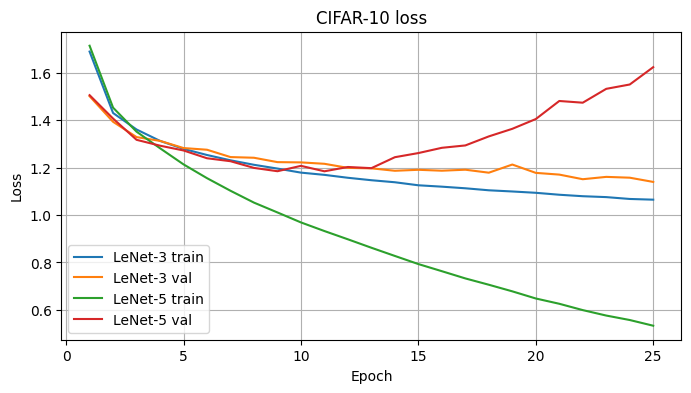

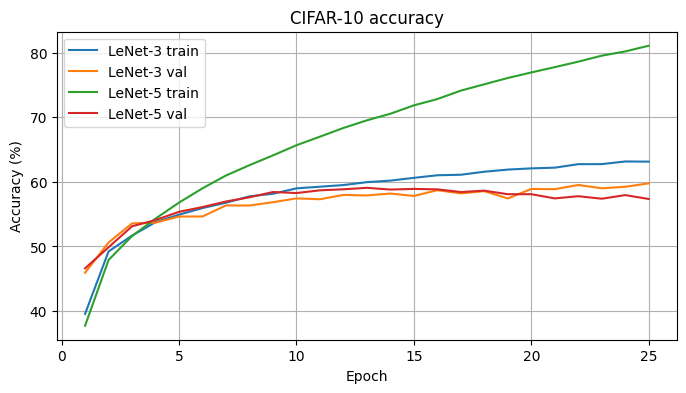

In [ ]:
def plot_pair(result3, result5, dataset_name):
    loss3, vloss3, acc3, vacc3 = result3
    loss5, vloss5, acc5, vacc5 = result5
    epochs = range(1, len(loss3) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, loss3, label="LeNet-3 train")
    plt.plot(epochs, vloss3, label="LeNet-3 val")
    plt.plot(epochs, loss5, label="LeNet-5 train")
    plt.plot(epochs, vloss5, label="LeNet-5 val")
    plt.grid()
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(dataset_name + " loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, acc3, label="LeNet-3 train")
    plt.plot(epochs, vacc3, label="LeNet-3 val")
    plt.plot(epochs, acc5, label="LeNet-5 train")
    plt.plot(epochs, vacc5, label="LeNet-5 val")
    plt.grid()
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(dataset_name + " accuracy")
    plt.legend()
    plt.show()

plot_pair(mnist_lenet3, mnist_lenet5, "MNIST")
plot_pair(cifar_lenet3, cifar_lenet5, "CIFAR-10")

# Cell 7: Testing

In [ ]:
def test(model, test_loader):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    test_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            test_loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    test_loss /= len(test_loader)
    test_accuracy = 100 * correct / total
    return test_loss, test_accuracy

for name, model, loader in [
    ("MNIST LeNet-5", mnist_m5, mnist_test_loader),
    ("MNIST LeNet-3", mnist_m3, mnist_test_loader),
    ("CIFAR-10 LeNet-5", cifar_m5, cifar_test_loader),
    ("CIFAR-10 LeNet-3", cifar_m3, cifar_test_loader),
]:
    loss, acc = test(model, loader)
    print(f"{name}: Test Loss {loss:.4f}, Test Accuracy {acc:.2f}%")

MNIST LeNet-5: Test Loss 0.0407, Test Accuracy 98.63%
MNIST LeNet-3: Test Loss 0.0442, Test Accuracy 98.64%
CIFAR-10 LeNet-5: Test Loss 1.6562, Test Accuracy 56.03%
CIFAR-10 LeNet-3: Test Loss 1.1524, Test Accuracy 59.53%


# Cell 8: Visualize results

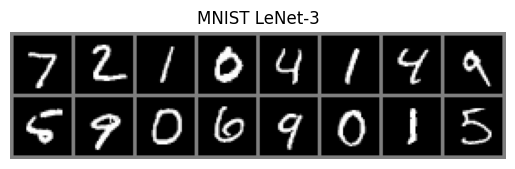

 0  truth: 7             predicted: 7
 1  truth: 2             predicted: 2
 2  truth: 1             predicted: 1
 3  truth: 0             predicted: 0
 4  truth: 4             predicted: 4
 5  truth: 1             predicted: 1
 6  truth: 4             predicted: 4
 7  truth: 9             predicted: 9
 8  truth: 5             predicted: 5
 9  truth: 9             predicted: 9
10  truth: 0             predicted: 0
11  truth: 6             predicted: 6
12  truth: 9             predicted: 9
13  truth: 0             predicted: 0
14  truth: 1             predicted: 1
15  truth: 5             predicted: 5


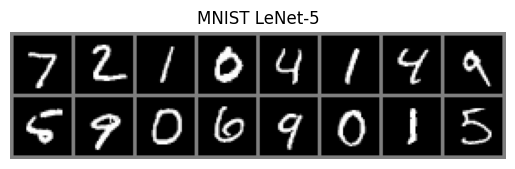

 0  truth: 7             predicted: 7
 1  truth: 2             predicted: 2
 2  truth: 1             predicted: 1
 3  truth: 0             predicted: 0
 4  truth: 4             predicted: 4
 5  truth: 1             predicted: 1
 6  truth: 4             predicted: 4
 7  truth: 9             predicted: 9
 8  truth: 5             predicted: 5
 9  truth: 9             predicted: 9
10  truth: 0             predicted: 0
11  truth: 6             predicted: 6
12  truth: 9             predicted: 9
13  truth: 0             predicted: 0
14  truth: 1             predicted: 1
15  truth: 5             predicted: 5


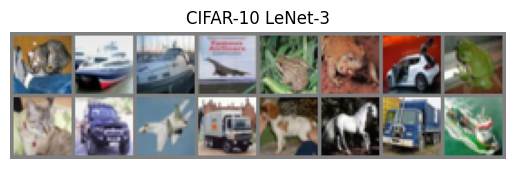

 0  truth: cat           predicted: cat
 1  truth: ship          predicted: ship
 2  truth: ship          predicted: airplane
 3  truth: airplane      predicted: airplane
 4  truth: frog          predicted: deer
 5  truth: frog          predicted: frog
 6  truth: automobile    predicted: automobile
 7  truth: frog          predicted: frog
 8  truth: cat           predicted: deer
 9  truth: automobile    predicted: automobile
10  truth: airplane      predicted: airplane
11  truth: truck         predicted: truck
12  truth: dog           predicted: dog
13  truth: horse         predicted: horse
14  truth: truck         predicted: truck
15  truth: ship          predicted: ship


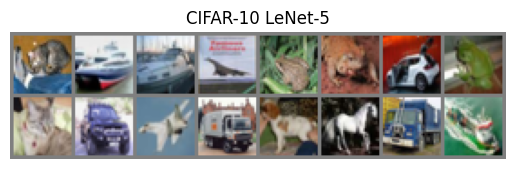

 0  truth: cat           predicted: cat
 1  truth: ship          predicted: automobile
 2  truth: ship          predicted: automobile
 3  truth: airplane      predicted: airplane
 4  truth: frog          predicted: deer
 5  truth: frog          predicted: frog
 6  truth: automobile    predicted: automobile
 7  truth: frog          predicted: bird
 8  truth: cat           predicted: cat
 9  truth: automobile    predicted: automobile
10  truth: airplane      predicted: airplane
11  truth: truck         predicted: truck
12  truth: dog           predicted: dog
13  truth: horse         predicted: horse
14  truth: truck         predicted: truck
15  truth: ship          predicted: dog


In [ ]:
def show_predictions(model, loader, title, names=None, n=16):
    images, labels = next(iter(loader))
    outputs = model(images.to(device))
    _, predicted = torch.max(outputs, 1)

    grid = utils.make_grid(images[:n]) / 2 + 0.5
    grid = grid.clamp(0, 1)                    # keep pixels inside 0–1, stops the warning
    plt.imshow(grid.permute(1, 2, 0))
    plt.title(title)
    plt.axis("off")
    plt.show()

    for j in range(n):
        t = labels[j].item()
        p = predicted[j].item()
        truth = names[t] if names else str(t)
        guess = names[p] if names else str(p)
        print(f"{j:2d}  truth: {truth:12s}  predicted: {guess}")

show_predictions(mnist_m5, mnist_test_loader, "MNIST LeNet-5")
show_predictions(mnist_m3, mnist_test_loader, "MNIST LeNet-3")
show_predictions(cifar_m5, cifar_test_loader, "CIFAR-10 LeNet-5", cifar_names)
show_predictions(cifar_m3, cifar_test_loader, "CIFAR-10 LeNet-3", cifar_names)